# Exploratory Data Analysis of `thesis_final.duckdb`

This notebook explores the `thesis_final.duckdb` database, which contains speeches from the UK House of Commons related to Brexit. The underlying `data_collection` workflow downloads debates from TheyWorkForYou, parses and cleans them, and classifies Brexit relevance with large language models. We begin with the structure of the database and then analyse core metrics around debates, speeches, and speakers.



In [8]:
from pathlib import Path

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", None)

search_roots = [Path.cwd().resolve()] + list(Path.cwd().resolve().parents)
for base in search_roots:
    candidate = base / "thesis_final.duckdb"
    if candidate.exists():
        db_path = candidate
        break
else:
    raise FileNotFoundError(
        "Could not locate `thesis_final.duckdb` in the current or any parent directories."
    )

con = duckdb.connect(database=str(db_path), read_only=True)
db_path


PosixPath('/Users/julianbeese/Developer/Master/master_thesis_data_analysis/thesis_final.duckdb')

## Database Structure
We start with an overview of all tables in the database and their size.


In [9]:
table_names = (
    con.execute(
        """
        SELECT table_name
        FROM information_schema.tables
        WHERE table_schema = 'main'
        ORDER BY table_name
        """
    )
    .fetchdf()
    ["table_name"]
)

summary = []
for table in table_names:
    row_count = con.execute(f'SELECT COUNT(*) FROM "{table}"').fetchone()[0]
    col_count = con.execute(f"SELECT COUNT(*) FROM pragma_table_info('{table}')").fetchone()[0]
    summary.append({"table": table, "rows": row_count, "columns": col_count})

pd.DataFrame(summary).sort_values("rows", ascending=False).reset_index(drop=True)


,table,rows,columns
0,chunks,62847,20
1,speeches,32087,32
2,debates,3171,8
3,MPS,1124,9


## Overall Volume
How many speeches, debates, and sitting days are covered in the database?


In [10]:
con.execute(
    """
    SELECT
        COUNT(DISTINCT s.speech_id) AS total_speeches,
        COUNT(DISTINCT s.debate_id) AS total_debates_with_speeches,
        COUNT(DISTINCT d.date) AS debate_days
    FROM speeches AS s
    LEFT JOIN debates AS d
        ON s.debate_id = d.debate_id
    """
).fetchdf()


,total_speeches,total_debates_with_speeches,debate_days
0,32087,3171,1274


## Speakers per Debate
How do speeches and distinct speakers distribute across individual debates?


In [11]:
speakers_per_debate = con.execute(
    """
    SELECT
        s.debate_id,
        d.major_heading_text,
        d.date,
        COUNT(*) AS speeches_in_debate,
        COUNT(DISTINCT s.speaker_name) AS unique_speakers
    FROM speeches AS s
    LEFT JOIN debates AS d
        ON s.debate_id = d.debate_id
    GROUP BY 1, 2, 3
    """
).fetchdf()

summary = (
    speakers_per_debate[["speeches_in_debate", "unique_speakers"]]
    .agg(["count", "mean", "median", "min", "max"])
    .rename(index={"count": "debates"})
)

display(summary)
display(
    speakers_per_debate
    .sort_values("unique_speakers", ascending=False)
    .head(10)
    [["debate_id", "major_heading_text", "date", "speeches_in_debate", "unique_speakers"]]
)



,speeches_in_debate,unique_speakers
debates,3171.00000,3171.000000
mean,10.11889,6.076001
median,3.00000,3.000000
min,1.00000,0.000000
max,242.00000,116.000000


,debate_id,major_heading_text,date,speeches_in_debate,unique_speakers
433,uk.org.publicwhip/debate/2017-01-31c.817.2,EUROPEAN UNION (NOTIFICATION OF WITHDRAWAL) BILL,2017-01-31,221,116
2444,uk.org.publicwhip/debate/2019-01-14b.823.3,LEAVING THE EU,2019-01-14,242,110
1622,uk.org.publicwhip/debate/2017-02-01b.1005.170,EUROPEAN UNION (NOTIFICATION OF WITHDRAWAL) BILL,2017-02-01,130,90
2000,uk.org.publicwhip/debate/2017-09-11a.455.0,EUROPEAN UNION (WITHDRAWAL) BILL,2017-09-11,135,90
1849,uk.org.publicwhip/debate/2018-12-06a.1059.0,BUSINESS OF THE HOUSE,2018-12-06,169,89
484,uk.org.publicwhip/debate/2019-01-15b.1019.0,EUROPEAN UNION (WITHDRAWAL) ACT,2019-01-15,140,79
2445,uk.org.publicwhip/debate/2019-01-21a.24.1,LEAVING THE EU,2019-01-21,128,71
1075,uk.org.publicwhip/debate/2018-12-17c.527.0,EUROPEAN COUNCIL,2018-12-17,133,69
1887,uk.org.publicwhip/debate/2019-10-19a.569.2,Prime Minister’s Statement,2019-10-19,133,68
1845,uk.org.publicwhip/debate/2018-11-15a.431.0,EU EXIT NEGOTIATIONS,2018-11-15,125,68


## Speakers per Day
How many people speak on a given sitting day and how many speeches are delivered?


In [12]:
speakers_per_day = con.execute(
    """
    SELECT
        d.date,
        COUNT(DISTINCT s.speaker_name) AS unique_speakers,
        COUNT(*) AS speeches
    FROM speeches AS s
    LEFT JOIN debates AS d
        ON s.debate_id = d.debate_id
    GROUP BY d.date
    ORDER BY d.date
    """
).fetchdf()

summary_day = speakers_per_day[["speeches", "unique_speakers"]].agg(["count", "mean", "median", "min", "max"])
display(summary_day)
display(speakers_per_day.sort_values("unique_speakers", ascending=False).head(10))



,speeches,unique_speakers
count,1274.000000,1274.000000
mean,25.186028,14.601256
median,10.000000,7.000000
min,1.000000,0.000000
max,255.000000,121.000000


,date,unique_speakers,speeches
478,2017-01-31,121,229
738,2019-01-14,118,255
724,2018-12-06,109,218
725,2018-12-10,104,210
479,2017-02-01,99,144
847,2019-09-25,96,156
536,2017-09-11,90,135
783,2019-03-27,88,198
844,2019-09-04,88,213
739,2019-01-15,85,149


## Yearly Overview
How do speeches, debates, and unique speakers evolve over time?


In [13]:
yearly_overview = con.execute(
    """
    SELECT
        CAST(EXTRACT(YEAR FROM d.date) AS INTEGER) AS year,
        COUNT(DISTINCT s.speech_id) AS speeches,
        COUNT(DISTINCT s.debate_id) AS debates,
        COUNT(DISTINCT s.speaker_name) AS unique_speakers
    FROM speeches AS s
    LEFT JOIN debates AS d
        ON s.debate_id = d.debate_id
    WHERE d.date IS NOT NULL
    GROUP BY year
    ORDER BY year
    """
).fetchdf()

summary_totals = yearly_overview[["speeches", "debates"]].sum().rename("sum_all_years")
summary_means = yearly_overview[["speeches", "debates"]].mean().rename("mean_per_year")

summary = pd.concat([summary_totals, summary_means], axis=1)

display(yearly_overview)
summary.T


,year,speeches,debates,unique_speakers
0,2012,386,63,121
1,2013,857,115,210
2,2014,478,119,157
3,2015,863,114,227
4,2016,3846,363,503
5,2017,5740,374,592
6,2018,6541,477,560
7,2019,8573,593,578
8,2020,2788,401,486
9,2021,982,276,295


,speeches,debates
sum_all_years,32087.0,3171.000000
mean_per_year,2917.0,288.272727


### Visualising Yearly Metrics
How do speeches, debates, and unique speakers develop year over year in a single chart?


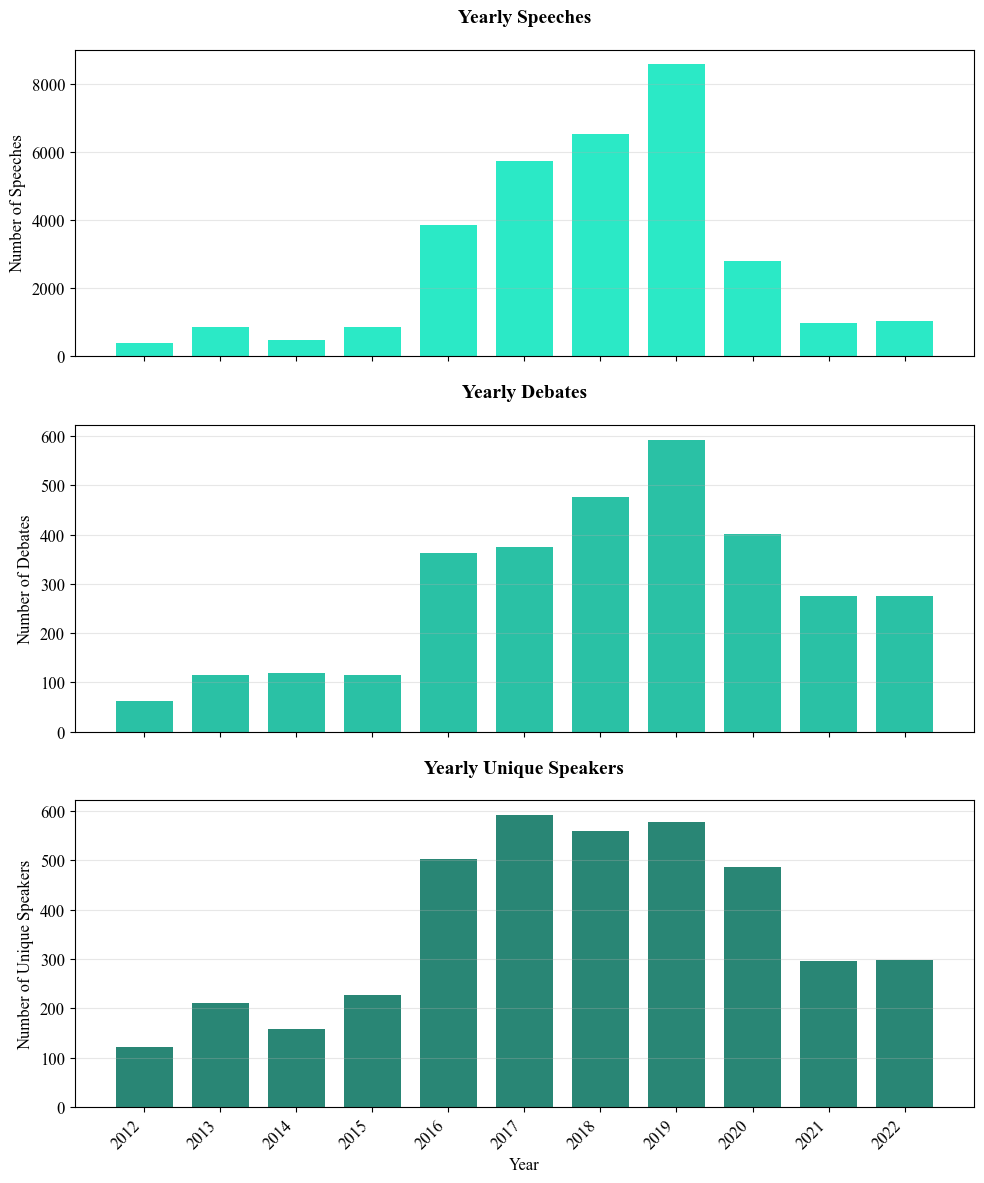

In [14]:
# Set font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

years = yearly_overview["year"].astype(str)
positions = np.arange(len(years))
bar_width = 0.75

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Plot 1: Speeches
axes[0].bar(positions, yearly_overview["speeches"], width=bar_width, color="#06E6BC", alpha=0.85)
axes[0].set_title("Yearly Speeches", fontsize=14, fontweight='bold', pad=20)
axes[0].set_ylabel("Number of Speeches", fontsize=12)
axes[0].tick_params(axis='y', labelsize=12)
axes[0].grid(axis="y", alpha=0.3)

# Plot 2: Debates
axes[1].bar(positions, yearly_overview["debates"], width=bar_width, color="#05B696", alpha=0.85)
axes[1].set_title("Yearly Debates", fontsize=14, fontweight='bold', pad=20)
axes[1].set_ylabel("Number of Debates", fontsize=12)
axes[1].tick_params(axis='y', labelsize=12)
axes[1].grid(axis="y", alpha=0.3)

# Plot 3: Unique Speakers
axes[2].bar(positions, yearly_overview["unique_speakers"], width=bar_width, color="#03715D", alpha=0.85)
axes[2].set_title("Yearly Unique Speakers", fontsize=14, fontweight='bold', pad=20)
axes[2].set_ylabel("Number of Unique Speakers", fontsize=12)
axes[2].set_xlabel("Year", fontsize=12)
axes[2].tick_params(axis='y', labelsize=12)
axes[2].tick_params(axis='x', labelsize=12)
axes[2].grid(axis="y", alpha=0.3)
axes[2].set_xticks(positions)
axes[2].set_xticklabels(years, rotation=45, ha='right')

plt.tight_layout()
plt.show()